In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D # Testei pra visualizar num gráfico 3D mas não adiantou muita coisa
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay

---
# 1. Carregamento dos dados:

In [5]:
# Importar o dataset
df = pd.read_csv('dataset_emprestimo_aprovacao.csv')

# Exibir as primeiras linhas
df.head()
df.tail()

df.sort_values(["renda_mensal"], ascending=[False])


,renda_mensal,score_credito,dividas_ativas,emprestimo_aprovado
62,19546.00,727,4,0
33,13314.00,654,5,0
68,13252.00,663,4,0
31,8204.56,658,2,1
73,7629.29,691,2,1
...,...,...,...,...
13,1200.00,900,3,0
37,1200.00,611,3,0
49,1200.00,686,3,1
79,1200.00,900,3,1


---
# 2. Análise exploratória

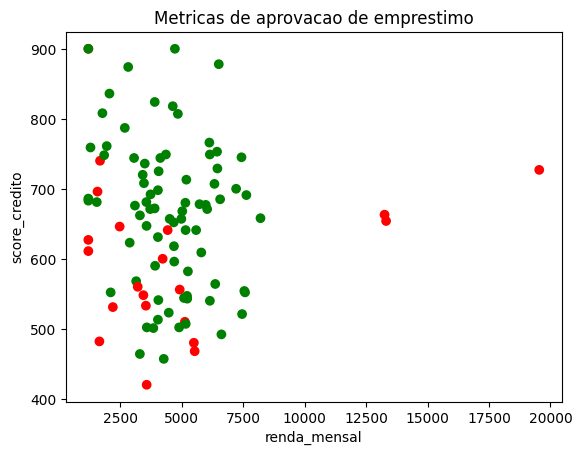

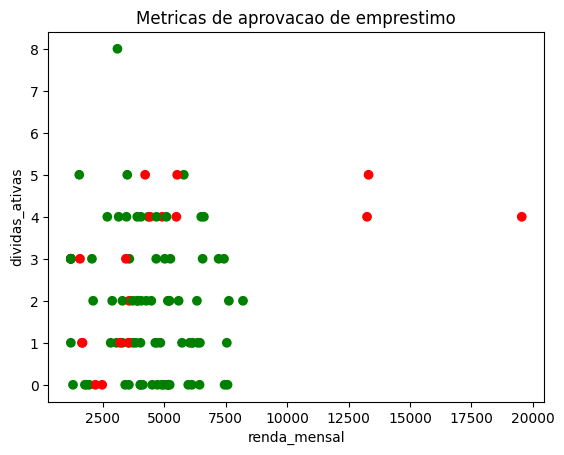

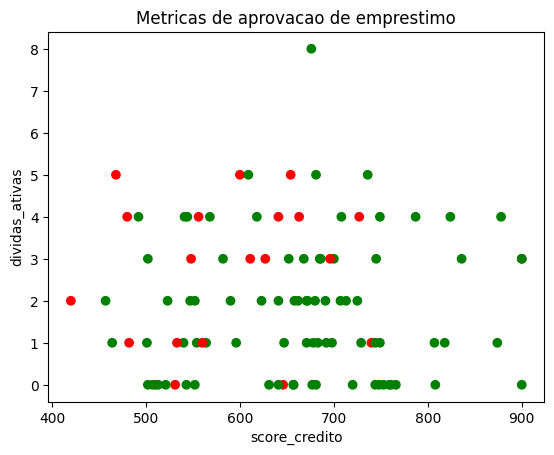

,renda_mensal,score_credito,dividas_ativas,emprestimo_aprovado
renda_mensal,1.000000,-0.070066,0.135866,-0.058644
score_credito,-0.070066,1.000000,0.003326,0.242901
dividas_ativas,0.135866,0.003326,1.000000,-0.207389
emprestimo_aprovado,-0.058644,0.242901,-0.207389,1.000000


In [6]:
# Análise exploratória

def gerar_grafico(campo_1, campo_2, campo_base):
  plt.scatter(df[campo_1], df[campo_2], c=df[campo_base].map({0: "red", 1: 'green'}))
  plt.xlabel(campo_1)
  plt.ylabel(campo_2)
  plt.title("Metricas de aprovacao de emprestimo")
  plt.show()

# Buscando encontrar relação entre renda mensal e score de crédito para a aprovação do empréstimo
gerar_grafico("renda_mensal", "score_credito", "emprestimo_aprovado")

print("\n\n")

# Buscando encontrar relação entre renda mensal e numero de dividas ativas para a aprovação do empréstimo
gerar_grafico("renda_mensal", "dividas_ativas", "emprestimo_aprovado")

print("\n\n")

# Buscando encontrar relação entre score de credito e numero de dividas ativas para a aprovação do empréstimo
gerar_grafico("score_credito", "dividas_ativas", "emprestimo_aprovado")


print('\n\n')

# Verificar possiveis relações entre as variáveis e a aprovação do empréstimo
df.corr()


- Observando os gráficos 2D individualmente, notamos que:

  - No primeiro e segundo gráfico, a renda mensal parece não ser um fator deterministico para a aprovação do empréstimo, haja visto que as tentativas de emprestimo com pessoas de renda maior que 10K não foram aprovadas
  - O score_credito aparenta ter uma relevância maior, haja visto que no gráfico 1 e 3 todas tentativas de empréstimo com score acima de =~ 760 foram aceitos.

- Observando a saída da função `corr()`  podemos observar que não há um padrão relevante o suficiente entre nenhuma das variáveis(nem "proporcional" nem "inversamente proporcional") para determinar as condições de aprovação do empréstimo.

---
# 3.Preparação dos Dados

In [7]:

# Separar as variáveis independentes(X) da variavel alvo(Y)

x = df[['renda_mensal', 'score_credito', 'dividas_ativas']]
y = df[['emprestimo_aprovado']]


# Dividir o dataset em treino e teste

x_train, x_test, y_train, y_test = train_test_split(
    x,y,
    test_size=0.3,
    random_state=45
)

# print(x_test, y_test)

---

# 4.Treinamento do Modelo
* Regressão Logística

In [8]:
# Treinamento do Modelo
modelo = LogisticRegression()
modelo.fit(x_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


LogisticRegression()

In [9]:
# Previsão do modelo

y_pred = modelo.predict(x_test)

print(f"Previsões")
print(f"{y_pred}")
print(f"{y_test}")

Previsões
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1]
    emprestimo_aprovado
0                     0
1                     0
62                    0
76                    1
37                    0
99                    1
78                    1
38                    1
2                     1
84                    1
60                    0
26                    0
69                    0
33                    0
51                    1
4                     1
92                    1
7                     1
10                    0
74                    1
45                    1
9                     1
20                    1
18                    1
73                    1
19                    0
25                    1
21                    1
70                    1
23                    0


---
# 5.Métricas de avaliação do modelo

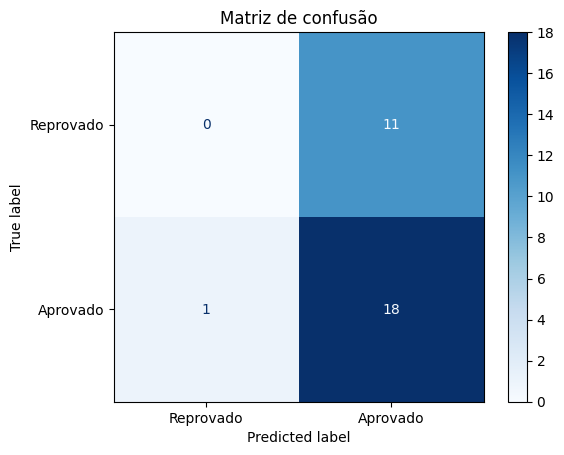

In [10]:
# Matriz de confusão

cm = confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Reprovado", "Aprovado"],
    cmap="Blues"
)

plt.title("Matriz de confusão")
plt.show()

- Pô....bem ruimKKKKKKKKKKKKKKKKK

In [11]:
# Acurácia

acc = accuracy_score(y_test, y_pred)
print(f"Acurácia: {acc}")

# Relatório de classificação
print(f"Relatório de Classificação:")
print(classification_report(y_test, y_pred))

Acurácia: 0.6
Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        11
           1       0.62      0.95      0.75        19

    accuracy                           0.60        30
   macro avg       0.31      0.47      0.38        30
weighted avg       0.39      0.60      0.47        30



In [12]:
# Teste individual de previsão
nova_tentativa = pd.DataFrame(
    {
        "renda_mensal": [0],
        "score_credito": [500],
        "dividas_ativas": [4]
    }
)

previsão = modelo.predict(nova_tentativa)
print(f"Previsão: {previsão}")

Previsão: [1]


---
# 6. Interpretação:

## Acurácia:
- O modelo teve uma "falsa acurácia" de 60%, pois ele está "viciado" em aprovar tudo.
- Precisão de 0%

## Variáveis
-  Na ultima previsão com métricas bastante ruins, observei que a analise do campo `renda_mensal` é na maior parte dos casos insignificante, conforme havia previsto mais acima.
- O campo `score_credito` e `dividas_ativas` apresentam uma relação baixa, porém perceptivel e mais relevante, à partir de certo ponto,(score > 5 && dividas ativas < 5) conforme tentavias manuais no teste individual de previsão e em gráficos.

---

No geral, a base de dados é bem inconsistente. Olhando o `df.sort_values(["renda_mensal"], ascending=[False])` no inicio do código, na sorte vi uma aberração braba:


```
"ID" | renda_mensal	| score_credito	| dividas_ativas |	emprestimo_aprovado
13   |    1200.00   |     900       |    	3        |      	0
79   |    1200.00   |     900       |    	3        |      	1
```

- Os 2 casos tem exatamente as mesmas condições mas resultados diferentes.